# Retinal OCT Classification: Сравнение стратегий обучения

**Цель работы** — построить модель бинарной классификации OCT-снимков сетчатки глаза.

Исходный датасет (Kermany2018) содержит четыре класса: `CNV`, `DME`, `DRUSEN`, `NORMAL`.
Для упрощения задачи классы `CNV`, `DME` и `DRUSEN` объединяются в единый класс **Disease** (1), а класс `NORMAL` формирует класс **Healthy** (0).

**Основная задача:** определить наличие патологии по OCT-снимку, обеспечив отсутствие утечки данных (Data Leakage) и честную валидацию с использованием метрик, применимых в медицинской диагностике (ROC-AUC, PR-AUC, F1).


In [1]:
!pip install -q albumentations timm grad-cam

import os
import glob
import random
import hashlib
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve, auc, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import train_test_split

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import kagglehub

# Фиксация Seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# Настройка устройства (CUDA -> MPS -> CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device --: {device}")

Device --: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from google.colab import drive
import os
import kagglehub

drive.mount('/content/drive')


drive_cache_path = "/content/drive/MyDrive/kaggle_cache/kaggle/input"
os.makedirs(drive_cache_path, exist_ok=True)

!rm -rf /root/.cache/kagglehub
!ln -s {drive_cache_path} /root/.cache/kagglehub


path = kagglehub.dataset_download("paultimothymooney/kermany2018")
print(f"Датасет загружен из кэша: {path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab cache for faster access to the 'kermany2018' dataset.
Датасет загружен из кэша: /kaggle/input/kermany2018


In [4]:




SAVE_DIR = os.path.abspath("model_weights")

os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Model weights will be saved to: {SAVE_DIR}")

# Проверка записи
test_file = os.path.join(SAVE_DIR, "write_test.txt")

with open(test_file, "w") as f:
    f.write("ok")

os.remove(test_file)

print("Save directory is writable")
# Download latest version
# path = kagglehub.dataset_download("paultimothymooney/kermany2018")

# path = '/Users/manul-chik/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2'

print("Path to dataset files:", path)

Model weights will be saved to: /content/model_weights
Save directory is writable
Path to dataset files: /kaggle/input/kermany2018


### Шаг 1: Контроль качества данных и устранение Data Leakage
В датасете Kermany2018 присутствует критическая проблема: часть изображений из тестовой выборки дублируется в обучающей. Выявим их с помощью хэширования (MD5) и составим список файлов на удаление из `train`.


In [5]:
base_path = os.path.join(path, "OCT2017 ")
train_dir = os.path.join(base_path, "train")
test_dir = os.path.join(base_path, "test")
val_dir = os.path.join(base_path, "val")

In [6]:
def md5(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

train_hashes = defaultdict(list)
test_hashes = defaultdict(list)

# Хэшируем train
for p in tqdm(glob.glob(os.path.join(train_dir, "*", "*.jpeg")), desc="Hashing Train"):
    train_hashes[md5(p)].append(p)

# Хэшируем test
for p in tqdm(glob.glob(os.path.join(test_dir, "*", "*.jpeg")), desc="Hashing Test"):
    test_hashes[md5(p)].append(p)

common_hashes = set(train_hashes.keys()) & set(test_hashes.keys())

duplicate_train_files = set()
for h in common_hashes:
    duplicate_train_files.update(train_hashes[h])

print("\n---DATA LEAKAGE ---")
print(f"Количество уникальных пересекающихся хэшей (test & train): {len(common_hashes)}")
print(f"Количество файлов в train_dir, подлежащих удалению: {len(duplicate_train_files)}")

print("\nПримеры путей к файлам, которые будут удалены из обучающей выборки (первые 5):")
for path in list(duplicate_train_files)[:5]:
    print(path)

Hashing Test: 100%|██████████| 968/968 [00:02<00:00, 341.77it/s]


---DATA LEAKAGE ---
Количество уникальных пересекающихся хэшей (test & train): 574
Количество файлов в train_dir, подлежащих удалению: 711

Примеры путей к файлам, которые будут удалены из обучающей выборки (первые 5):
/kaggle/input/kermany2018/OCT2017 /train/NORMAL/NORMAL-33637-4.jpeg
/kaggle/input/kermany2018/OCT2017 /train/DRUSEN/DRUSEN-8870525-11.jpeg
/kaggle/input/kermany2018/OCT2017 /train/CNV/CNV-5409617-135.jpeg
/kaggle/input/kermany2018/OCT2017 /train/DRUSEN/DRUSEN-2489093-6.jpeg
/kaggle/input/kermany2018/OCT2017 /train/DRUSEN/DRUSEN-9624303-5.jpeg


Размер обучающей выборки ИСХОДНЫЙ (все файлы ImageFolder): 83484
Найдено и удалено файлов (Data Leakage): 711
Размер обучающей выборки ПОСЛЕ очистки: 82773


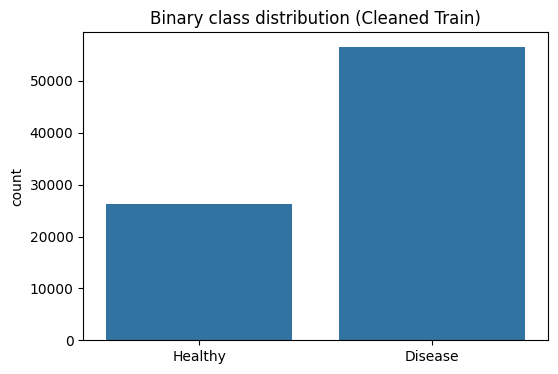


Распределение классов после удаления утечки:
1    56536
0    26237
Name: count, dtype: int64


In [7]:
binary_mapping = {0: 1, 1: 1, 2: 1, 3: 0} # CNV(0), DME(1), DRUSEN(2) -> Disease(1); NORMAL(3) -> Healthy(0)

def binary_target(label):
    return binary_mapping[label]

# Базовая загрузка (считывает все физические файлы в папке)
full_train_dataset_raw = ImageFolder(root=train_dir)

original_size = len(full_train_dataset_raw.samples)
print(f"Размер обучающей выборки ИСХОДНЫЙ (все файлы ImageFolder): {original_size}")

# ОЧИСТКА ОТ УТЕЧКИ (DATA LEAKAGE REMOVAL)
clean_samples = []
removed_count = 0

for file_path, target in full_train_dataset_raw.samples:
    # Важно: ImageFolder может использовать абсолютные пути, проверяем совпадение корректно
    if file_path not in duplicate_train_files:
        clean_samples.append((file_path, target))
    else:
        removed_count += 1

new_size = len(clean_samples)

print(f"Найдено и удалено файлов (Data Leakage): {removed_count}")
print(f"Размер обучающей выборки ПОСЛЕ очистки: {new_size}")

# Обязательные инженерные проверки (Asserts)
assert original_size - removed_count == new_size, "Ошибка логики: Базовый размер минус удалённые не равен новому размеру!"
assert removed_count == len(duplicate_train_files), f"Удалено {removed_count} файлов, но по хэшам ожидалось {len(duplicate_train_files)}!"

# Подменяем samples и targets на очищенные
full_train_dataset_raw.samples = clean_samples
full_train_dataset_raw.targets = [s[1] for s in clean_samples]

# Проверка распределения после чистки
binary_labels = [binary_mapping[label] for label in full_train_dataset_raw.targets]

plt.figure(figsize=(6,4))
sns.countplot(x=binary_labels, stat='count')
plt.xticks([0,1], ['Healthy', 'Disease'])
plt.title("Binary class distribution (Cleaned Train)")
plt.show()

print("\nРаспределение классов после удаления утечки:")
print(pd.Series(binary_labels).value_counts())



# EDA для очищенного от дупликатов датасета

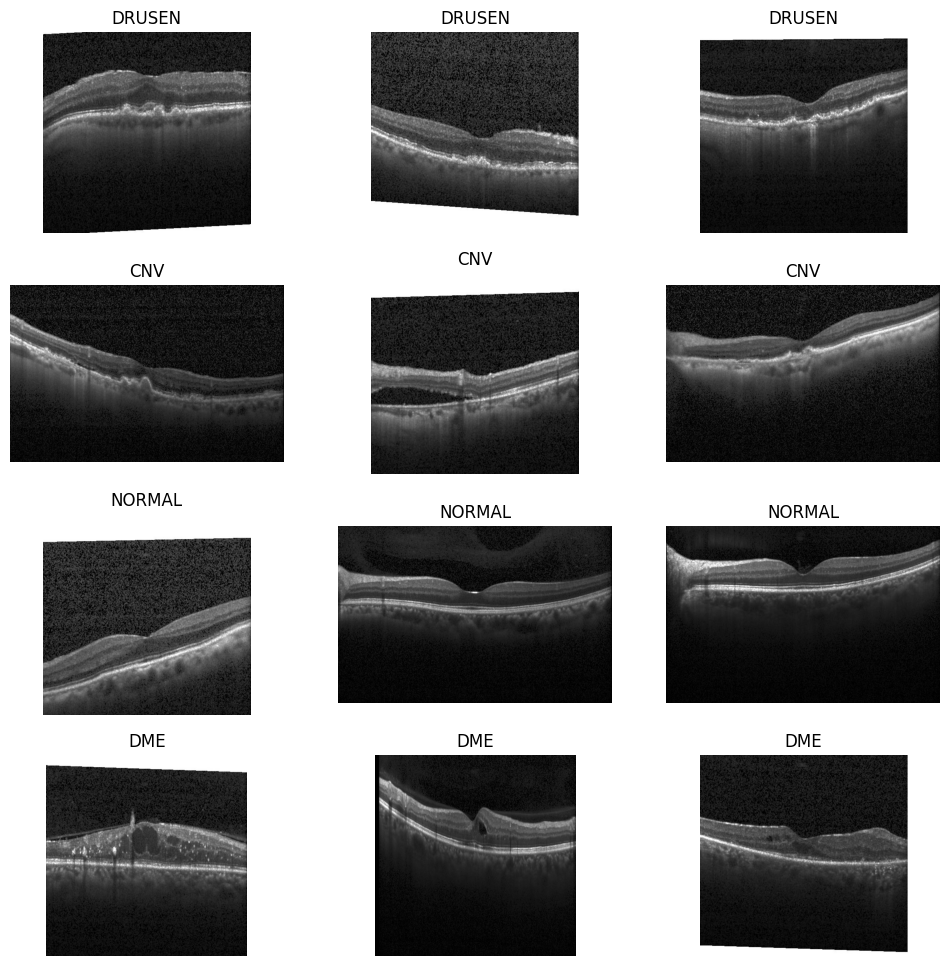

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(12, 12))

classes = os.listdir(train_dir)

for row, class_name in enumerate(classes):

    class_path = os.path.join(train_dir, class_name)

    images = os.listdir(class_path)[:3]

    for col, image_name in enumerate(images):

        image_path = os.path.join(class_path, image_name)

        image = Image.open(image_path)

        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

In [9]:
SAMPLE_SIZE_EDA = 1000



modes = []
sizes = []

for file_path, _ in tqdm(clean_samples[:SAMPLE_SIZE_EDA], desc="Scanning images"):
    with Image.open(file_path) as img:
        modes.append(img.mode)
        sizes.append(img.size)

# 1. Анализ цветового режима (Mode)
unique_modes = pd.Series(modes).value_counts()
print(f"\n1. Цветовые режимы (Mode):\n{unique_modes}")

# 2. Анализ размеров (Size)
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Анализ размеров:")
print(f"Ширина (Width):min={min(widths)}, max={max(widths)}")
print(f"Высота (Height): min={min(heights)}, max={max(heights)}")
print(f"Уникальных разрешений: {len(set(sizes))}")

Scanning images: 100%|██████████| 1000/1000 [00:01<00:00, 882.16it/s]


1. Цветовые режимы (Mode):
L    1000
Name: count, dtype: int64
Анализ размеров:
Ширина (Width):min=512, max=1536
Высота (Height): min=496, max=496
Уникальных разрешений: 4


Анализ очищенной обучающей выборки показывает, что OCT-снимки представлены в grayscale-формате (`mode='L'`) и имеют различные исходные размеры. Поэтому для использования предобученных сетей изображения приводятся к размеру 224×224 и преобразуются в 3-канальный формат. После бинаризации классов наблюдается выраженный дисбаланс между Healthy и Disease, поэтому при обучении необходимо использовать `WeightedRandomSampler`.

## Подготовка аугментаций для датасета
Для обучения использовались мягкие аугментации: `Horizontal Flip (p=0.5)` и `Random Rotation (5°)`. В задачах медицинской диагностики (и стандартах MIDRC) чрезмерно агрессивные деформации (сильный поворот, crop, искажение масштаба) могут уничтожить клинически значимые паттерны или сформировать нереалистичные артефакты сетчатки. Выбранные трансформации повышают робастность к позиционированию пациента без потери анатомической структуры.


In [10]:
transform_train_eff = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #ImageNet normalize
])

transform_val_eff = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [11]:
# Применяем трансформации к очищенному датасету
full_train_dataset = ImageFolder(
    root=train_dir,
    transform=transform_train_eff,
    target_transform=binary_target
    )
full_train_dataset.samples = clean_samples # Важно: применяем очищенные сэмплы
full_train_dataset.targets = [s[1] for s in clean_samples]

test_dataset = ImageFolder(
    root=test_dir,
    transform=transform_val_eff,
    target_transform=binary_target
    )

In [12]:
# Стратифицированное разбиение Train/Val
indices = np.arange(len(full_train_dataset))
targets_binary = [binary_mapping[label] for label in full_train_dataset.targets]

train_idx, val_idx = train_test_split(
    indices, test_size=0.15, stratify=targets_binary, random_state=SEED
)

train_dataset = Subset(full_train_dataset, train_idx)


# Для валидации нужен датасет без аугментаций (transform_val_eff)
full_val_dataset = ImageFolder(root=train_dir, transform=transform_val_eff, target_transform=binary_target)
full_val_dataset.samples = clean_samples
full_val_dataset.targets = [s[1] for s in clean_samples]
val_dataset = Subset(full_val_dataset, val_idx)

# Компенсация дисбаланса через WeightedRandomSampler
train_labels = [targets_binary[idx] for idx in train_idx]
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = [class_weights[label] for label in train_labels]

sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Проверка размерностей (Check)
images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}") # Ожидается: [32 - batch, 3 - chanels, 224- H, 224-W]
print(f"Batch labels shape: {labels.shape}")
print(f"Распределение классов в батче: {np.bincount(labels.numpy())}")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Распределение классов в батче: [14 18]


In [13]:
# Цикл обучения и валидации
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.float().to(device)

        optimizer.zero_grad()
        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    return running_loss / len(dataloader), f1_score(all_labels, all_preds)

def validate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_probs, all_preds, all_labels = [], [], []

    with torch.inference_mode():
        for images, labels in tqdm(dataloader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.float().to(device)
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)

            running_loss += loss.item()
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_f1 = f1_score(all_labels, all_preds)
    epoch_roc_auc = roc_auc_score(all_labels, all_probs)

    # Расчет PR AUC
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    epoch_pr_auc = auc(recall, precision)

    return epoch_loss, epoch_f1, epoch_roc_auc, epoch_pr_auc

def run_experiment(model, train_loader, val_loader, optimizer, criterion, epochs, save_name):
    history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[], 'val_roc_auc':[], 'val_pr_auc':[]}

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        t_loss, t_f1 = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_f1, v_roc, v_pr = validate_model(model, val_loader, criterion, device)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_f1'].append(t_f1)
        history['val_f1'].append(v_f1)
        history['val_roc_auc'].append(v_roc)
        history['val_pr_auc'].append(v_pr)

        print(f"Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")
        print(f"Train F1: {t_f1:.4f} | Val F1: {v_f1:.4f} | Val ROC-AUC: {v_roc:.4f} | Val PR-AUC: {v_pr:.4f}\n")

    save_path = os.path.join(SAVE_DIR, f"{save_name}.pth")
    torch.save(model.state_dict(), save_path)

    print(f"Model saved to: {save_path}")
    return history

In [14]:
def plot_training_history(history, title_prefix=""):
    epochs_range = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"{title_prefix} Training Dynamics", fontsize=16, y=1.02)

    # 1. Loss (Train vs Val) - контроль переобучения
    sns.lineplot(x=epochs_range, y=history['train_loss'], label='Train Loss', marker='o', ax=axes[0,0])
    sns.lineplot(x=epochs_range, y=history['val_loss'], label='Val Loss', marker='o', ax=axes[0,0])
    axes[0,0].set_title("Loss (BCE)")
    axes[0,0].set_xlabel("Epoch")
    axes[0,0].set_ylabel("Loss")
    axes[0,0].grid(True, alpha=0.3)

    # 2. F1-score (Train vs Val)
    sns.lineplot(x=epochs_range, y=history['train_f1'], label='Train F1', marker='o', ax=axes[0,1])
    sns.lineplot(x=epochs_range, y=history['val_f1'], label='Val F1', marker='o', ax=axes[0,1])
    axes[0,1].set_title("F1-Score")
    axes[0,1].set_xlabel("Epoch")
    axes[0,1].set_ylabel("F1")
    axes[0,1].grid(True, alpha=0.3)

    # 3. ROC-AUC (Val)
    sns.lineplot(x=epochs_range, y=history['val_roc_auc'], label='Val ROC-AUC', marker='o', color='green', ax=axes[1,0])
    axes[1,0].set_title("Validation ROC-AUC")
    axes[1,0].set_xlabel("Epoch")
    axes[1,0].set_ylabel("ROC-AUC")
    axes[1,0].grid(True, alpha=0.3)

    # 4. PR-AUC (Val) - критично для мед. диагностики при дисбалансе
    sns.lineplot(x=epochs_range, y=history['val_pr_auc'], label='Val PR-AUC', marker='o', color='purple', ax=axes[1,1])
    axes[1,1].set_title("Validation PR-AUC")
    axes[1,1].set_xlabel("Epoch")
    axes[1,1].set_ylabel("PR-AUC")
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
### Эксперимент 1: Baseline (Замороженный бэкбон EfficientNet-B0)
model_base = timm.create_model('efficientnet_b0', pretrained=True, num_classes=1).to(device)

# Замораживаем features, учим только classifier
for param in model_base.parameters():
    param.requires_grad = False
for param in model_base.classifier.parameters():
    param.requires_grad = True

criterion = nn.BCEWithLogitsLoss()
optimizer_base = torch.optim.Adam(model_base.classifier.parameters(), lr=3e-4)

# Проверка выхода сети
images, labels = next(iter(train_loader))
outputs = model_base(images.to(device))
print(f"Model output shape: {outputs.shape}") #  [32, 1]

hist_base = run_experiment(model_base, train_loader, val_loader, optimizer_base, criterion, epochs=5, save_name="effnet_baseline")
plot_training_history(hist_base, title_prefix="Baseline (Frozen Backbone)")

### Эксперимент 2: Fine-Tuning
Размораживаем все веса предыдущей модели и обучаем с малым learning rate.

In [15]:
# 1. Создаём архитектуру (без претренированных весов ImageNet,
#    потому что мы загрузим свои, но num_classes=1 должен совпадать)
model_ft = timm.create_model(
    'efficientnet_b0',
    pretrained=False,
    num_classes=1
).to(device)

# 2. Загружаем веса baseline (КРИТИЧЕСКИ ВАЖНО)
baseline_path = os.path.join(SAVE_DIR, "effnet_baseline.pth")

model_ft.load_state_dict(
    torch.load(
        baseline_path,
        map_location=device,
        weights_only=True
    )
)

print("Baseline weights loaded successfully")

# 3. Теперь размораживаем ВСЕ слои для fine-tuning
for param in model_ft.parameters():
    param.requires_grad = True

# 4. Оптимизатор с малым LR (чтобы не сломать хорошие веса)
optimizer_ft = torch.optim.Adam(
    model_ft.parameters(),
    lr=1e-5  # Низкий LR для fine-tuning
)
criterion = nn.BCEWithLogitsLoss()
# 5. Проверка
images, labels = next(iter(train_loader))
outputs = model_ft(images.to(device))
print(f"Model output shape: {outputs.shape}")  # [32, 1]

# 6. Запуск
hist_ft = run_experiment(
    model_ft,
    train_loader,
    val_loader,
    optimizer_ft,
    criterion,
    epochs=3,
    save_name="effnet_finetuned"
)
















Baseline weights loaded successfully
Model output shape: torch.Size([32, 1])
Epoch 1/3


Train Loss: 0.2477 | Val Loss: 0.1834
Train F1: 0.9272 | Val F1: 0.9621 | Val ROC-AUC: 0.9881 | Val PR-AUC: 0.9950

Epoch 2/3


Train Loss: 0.1427 | Val Loss: 0.1281
Train F1: 0.9554 | Val F1: 0.9708 | Val ROC-AUC: 0.9917 | Val PR-AUC: 0.9966

Epoch 3/3


Train Loss: 0.1028 | Val Loss: 0.0997
Train F1: 0.9668 | Val F1: 0.9749 | Val ROC-AUC: 0.9941 | Val PR-AUC: 0.9976

Model saved to: /content/model_weights/effnet_finetuned.pth


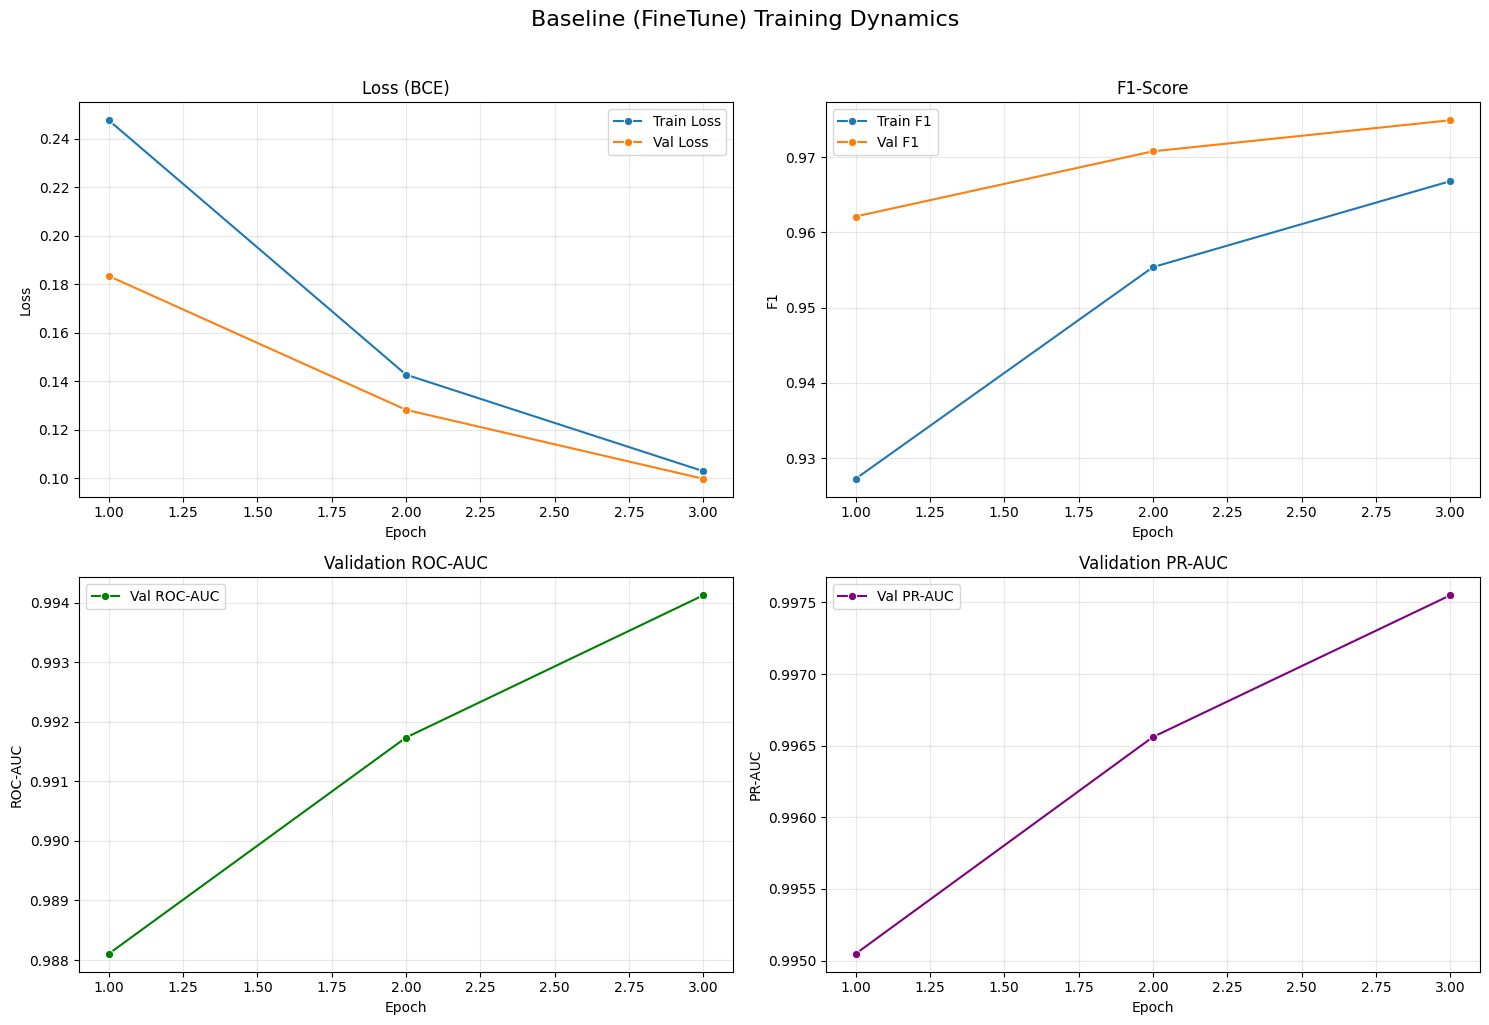

In [17]:
plot_training_history(hist_ft, title_prefix="Baseline (FineTune)")

### Эксперимент 3: Влияние CLAHE на предобработку
Попробуем усилить контрастность снимков, чтобы проверить гипотезу об улучшении извлечения признаков.


In [18]:
class CLAHETransform:
    def __call__(self, img):
        img = np.array(img.convert("L"), dtype=np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        return Image.fromarray(clahe.apply(img))

transform_train_clahe = transforms.Compose([
    CLAHETransform(),
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val_clahe = transforms.Compose([
    CLAHETransform(),
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [19]:
# Применяем CLAHE к очищенным сэмплам
ds_train_clahe = ImageFolder(
    root=train_dir,
    transform=transform_train_clahe,
    target_transform=binary_target
    )
ds_train_clahe.samples = clean_samples
ds_train_clahe.targets = [s[1] for s in clean_samples]
train_dataset_clahe = Subset(ds_train_clahe, train_idx)


ds_val_clahe = ImageFolder(
    root=train_dir,
    transform=transform_val_clahe,
    target_transform=binary_target
    )
ds_val_clahe.samples = clean_samples
ds_val_clahe.targets = [s[1] for s in clean_samples]
val_dataset_clahe = Subset(ds_val_clahe, val_idx)

test_dataset_clahe = ImageFolder(
    root=test_dir,
    transform=transform_val_clahe,
    target_transform=binary_target
    )

tl_clahe = DataLoader(train_dataset_clahe, batch_size=32, sampler=sampler, num_workers=2)
vl_clahe = DataLoader(val_dataset_clahe, batch_size=32, shuffle=False, num_workers=2)
test_loader_clahe = DataLoader(test_dataset_clahe, batch_size=32, shuffle=False, num_workers=2)

In [20]:
model_clahe = timm.create_model('efficientnet_b0', pretrained=True, num_classes=1).to(device)
for param in model_clahe.parameters(): param.requires_grad = False
for param in model_clahe.classifier.parameters(): param.requires_grad = True

opt_clahe = torch.optim.Adam(model_clahe.classifier.parameters(), lr=3e-4)
hist_clahe = run_experiment(model_clahe, tl_clahe, vl_clahe, opt_clahe, criterion, epochs=6, save_name="effnet_clahe")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 1/6


Train Loss: 1.2591 | Val Loss: 0.8090
Train F1: 0.6924 | Val F1: 0.8274 | Val ROC-AUC: 0.8630 | Val PR-AUC: 0.9325

Epoch 2/6


Train Loss: 0.6608 | Val Loss: 0.6313
Train F1: 0.8121 | Val F1: 0.8648 | Val ROC-AUC: 0.9109 | Val PR-AUC: 0.9585

Epoch 3/6


Train Loss: 0.5411 | Val Loss: 0.5361
Train F1: 0.8407 | Val F1: 0.8819 | Val ROC-AUC: 0.9292 | Val PR-AUC: 0.9676

Epoch 4/6


Train Loss: 0.4881 | Val Loss: 0.4569
Train F1: 0.8548 | Val F1: 0.8942 | Val ROC-AUC: 0.9373 | Val PR-AUC: 0.9716

Epoch 5/6


Train Loss: 0.4439 | Val Loss: 0.4179
Train F1: 0.8644 | Val F1: 0.9015 | Val ROC-AUC: 0.9429 | Val PR-AUC: 0.9743

Epoch 6/6


Train Loss: 0.4193 | Val Loss: 0.4182
Train F1: 0.8681 | Val F1: 0.9001 | Val ROC-AUC: 0.9449 | Val PR-AUC: 0.9752

Model saved to: /content/model_weights/effnet_clahe.pth


### Шаг 5: Итоговая Оценка на Тестовой Выборке (Всех моделей)
Сравниваем Baseline, CLAHE и Fine-Tuned модели на абсолютно независимых (и отчищенных от утечки) тестовых данных. Строим ROC и PR кривые.


In [26]:
def evaluate_on_test(model_path, loader, name):
    model = timm.create_model("efficientnet_b0", pretrained=False, num_classes=1).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_labels, all_preds, all_probs = [], [], []
    with torch.inference_mode():
        for images, labels in tqdm(loader, desc=f"Testing {name}", leave=False):
            images = images.to(device)
            logits = model(images).squeeze(1)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int()

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print(f"\n {name} Test Results")
    print(classification_report(all_labels, all_preds, target_names=["Healthy", "Disease"]))

    roc_auc = roc_auc_score(all_labels, all_probs)
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall, precision)
    f1 = f1_score(all_labels, all_preds)

    return all_labels, all_preds, all_probs, roc_auc, pr_auc, f1

In [27]:
# Тестируем все модели
res_base = evaluate_on_test("/content/model_weights/effnet_baseline.pth", test_loader, "Baseline")
res_clahe = evaluate_on_test("/content/model_weights/effnet_clahe.pth", test_loader_clahe, "CLAHE")
res_ft = evaluate_on_test("/content/model_weights/effnet_finetuned.pth", test_loader, "Fine-Tuned")


 Baseline Test Results
              precision    recall  f1-score   support

     Healthy       0.70      0.94      0.80       242
     Disease       0.98      0.87      0.92       726

    accuracy                           0.89       968
   macro avg       0.84      0.90      0.86       968
weighted avg       0.91      0.89      0.89       968




 CLAHE Test Results
              precision    recall  f1-score   support

     Healthy       0.72      0.97      0.83       242
     Disease       0.99      0.88      0.93       726

    accuracy                           0.90       968
   macro avg       0.85      0.92      0.88       968
weighted avg       0.92      0.90      0.90       968




 Fine-Tuned Test Results
              precision    recall  f1-score   support

     Healthy       0.98      1.00      0.99       242
     Disease       1.00      0.99      1.00       726

    accuracy                           1.00       968
   macro avg       0.99      1.00      0.99       968
weighted avg       1.00      1.00      1.00       968



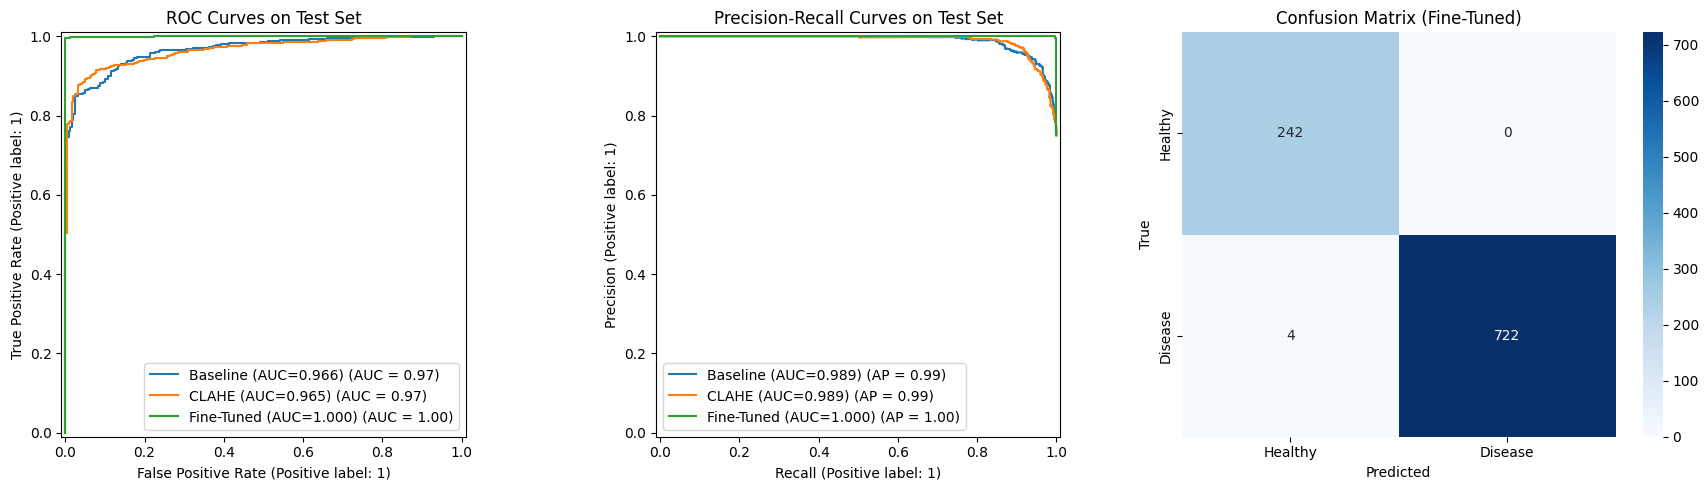

In [28]:
# Построение графиков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Сравнение ROC-кривых
for res, name in zip([res_base, res_clahe, res_ft], ["Baseline", "CLAHE", "Fine-Tuned"]):
    RocCurveDisplay.from_predictions(res[0], res[2], ax=axes[0], name=f"{name} (AUC={res[3]:.3f})")
axes[0].set_title("ROC Curves on Test Set")

# 2. Сравнение PR-кривых
for res, name in zip([res_base, res_clahe, res_ft], ["Baseline", "CLAHE", "Fine-Tuned"]):
    PrecisionRecallDisplay.from_predictions(res[0], res[2], ax=axes[1], name=f"{name} (AUC={res[4]:.3f})")
axes[1].set_title("Precision-Recall Curves on Test Set")

# 3. Confusion Matrix для Лучшей Модели (Fine-Tuned)
cm = confusion_matrix(res_ft[0], res_ft[1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2], xticklabels=["Healthy", "Disease"], yticklabels=["Healthy", "Disease"])
axes[2].set_title("Confusion Matrix (Fine-Tuned)")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()

In [29]:
# Итоговая таблица
results_df = pd.DataFrame({
    "Model": ["Baseline", "CLAHE", "Fine-Tuning"],
    "F1-Score": [res_base[5], res_clahe[5], res_ft[5]],
    "ROC-AUC": [res_base[3], res_clahe[3], res_ft[3]],
    "PR-AUC": [res_base[4], res_clahe[4], res_ft[4]]
})
display(results_df)

,Model,F1-Score,ROC-AUC,PR-AUC
0,Baseline,0.919037,0.966071,0.989165
1,CLAHE,0.928467,0.965064,0.989000
2,Fine-Tuning,0.997238,0.999653,0.999891


Выводы по сравнению экспериментальных стратегий

В работе были сопоставлены три стратегии обучения модели EfficientNet-B0 для бинарной классификации OCT-снимков сетчатки:
1. Baseline

Базовый пайплайн с использованием предобученного EfficientNet-B0 и обучением только классификационной головы продемонстрировал высокое качество уже без сложной донастройки признакового пространства. Это подтверждает, что даже стандартный transfer learning хорошо работает на OCT-изображениях.

2. CLAHE

Добавление CLAHE-предобработки не ухудшило качество модели и даже дало небольшой прирост F1-score по сравнению с baseline. При этом ROC-AUC и PR-AUC остались практически на том же уровне. Это позволяет сделать вывод, что локальное повышение контрастности может быть полезным для улучшения пороговой классификации, но не меняет принципиально способность модели отделять классы во всём диапазоне порогов.

3. Fine-Tuning

Наилучшие результаты были получены при разморозке всей архитектуры и последующем fine-tuning с малым learning rate. Это говорит о том, что адаптация признакового пространства под специфику OCT-снимков значительно эффективнее, чем обучение только верхнего классификатора. На тестовой выборке модель достигла почти идеальных значений ROC-AUC и PR-AUC.



Основной прирост качества обеспечивается именно fine-tuning всей сети. CLAHE может рассматриваться как дополнительный инструмент предобработки, но его влияние значительно слабее, чем влияние дообучения весов всей архитектуры.

При этом столь высокие тестовые метрики следует интерпретировать осторожно: датасет Kermany2018 является удобным benchmark-набором, но не эквивалентен реальному клиническому распределению данных. Поэтому полученные результаты не следует напрямую переносить на production или клиническую практику без внешней валидации.

### Шаг 6: Интерпретируемость через Grad-CAM (Только для лучшей модели)
Демонстрация того, что модель ориентируется на клинически значимые признаки, а не артефакты изображения.

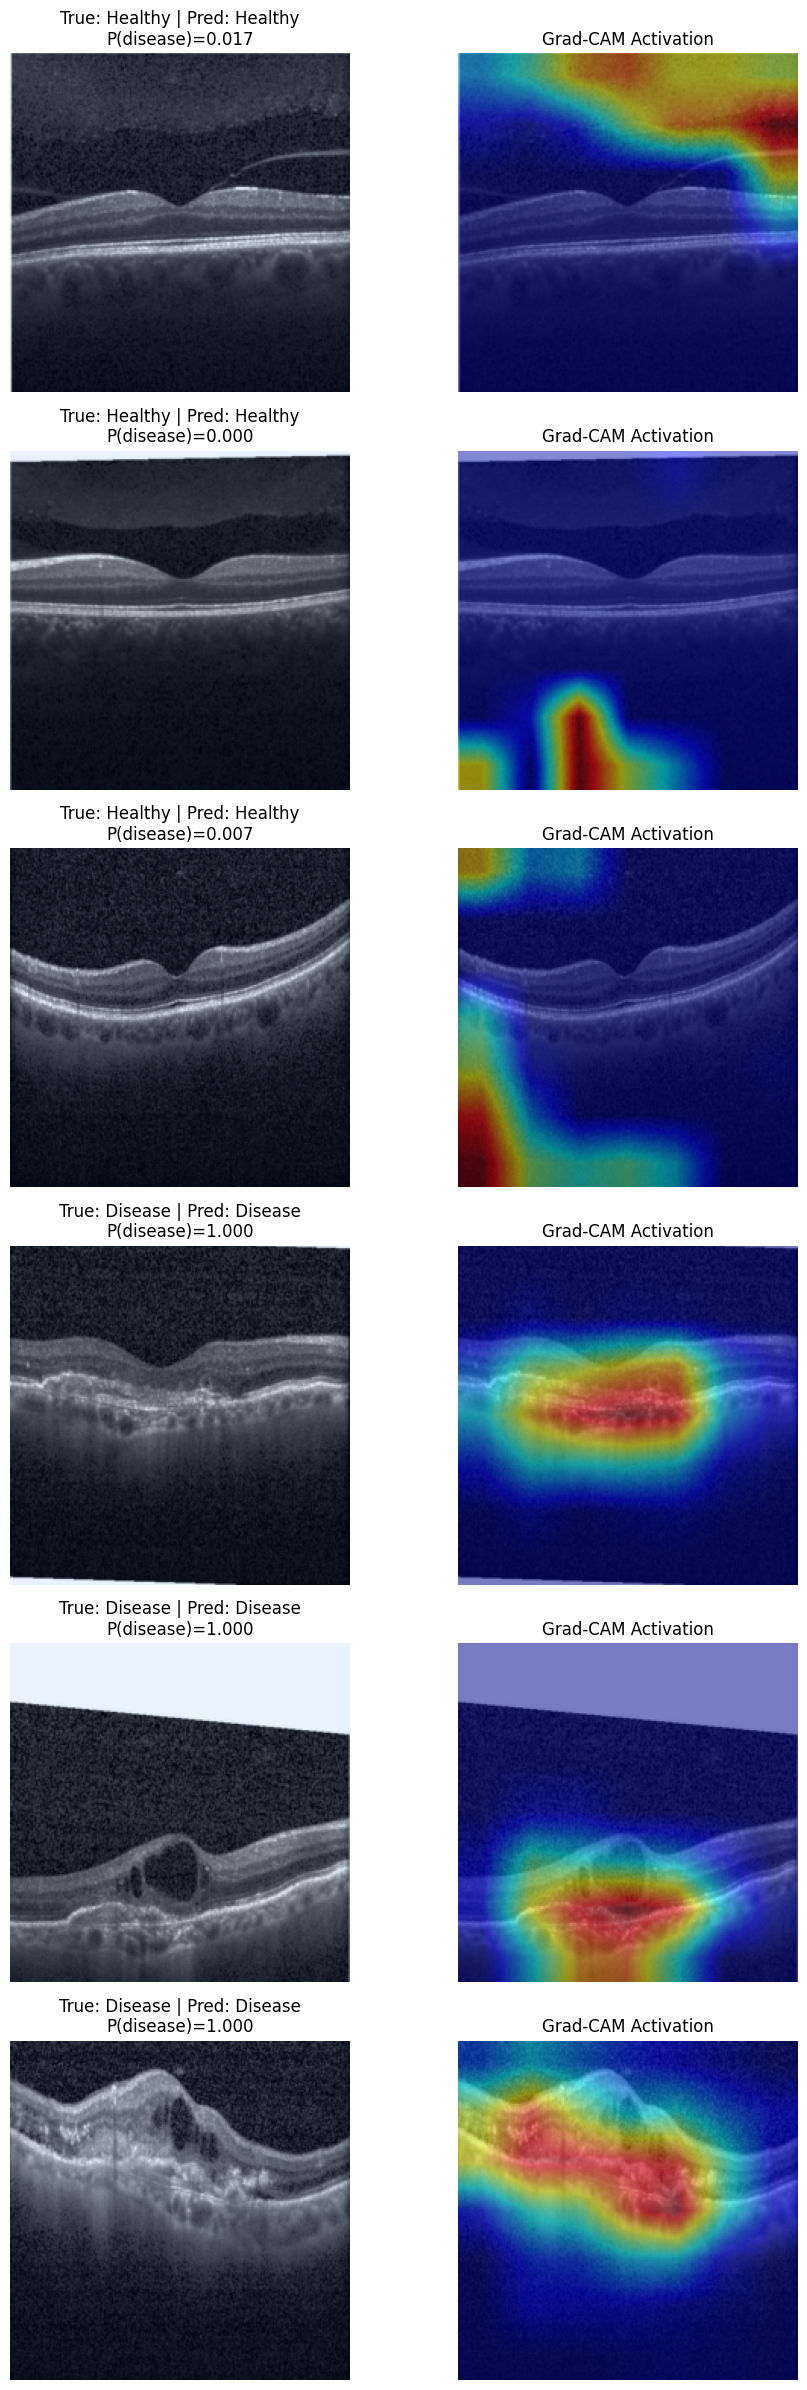

In [33]:
model_ft = timm.create_model("efficientnet_b0", pretrained=False, num_classes=1).to(device)
model_ft.load_state_dict(torch.load("/content/model_weights/effnet_finetuned.pth", map_location=device, weights_only=True))
model_ft.eval()

# Разрешаем градиенты для GradCAM
for param in model_ft.parameters():
    param.requires_grad = True

target_layers = [model_ft.conv_head]
cam = GradCAM(model=model_ft, target_layers=target_layers)

# Берем 3 здоровых и 3 больных
healthy_idx, disease_idx = [], []
for idx in range(len(test_dataset)):
    _, label = test_dataset[idx]
    if label == 0 and len(healthy_idx) < 3: healthy_idx.append(idx)
    if label == 1 and len(disease_idx) < 3: disease_idx.append(idx)
    if len(healthy_idx) == 3 and len(disease_idx) == 3: break

selected_idx = healthy_idx + disease_idx
fig, axes = plt.subplots(6, 2, figsize=(10, 24))
class_names = {0: "Healthy", 1: "Disease"}

for row, idx in enumerate(selected_idx):
    image, label = test_dataset[idx]
    input_tensor = image.unsqueeze(0).to(device)

    # Предсказание
    with torch.inference_mode():
        prob = torch.sigmoid(model_ft(input_tensor)).item()
        pred = int(prob > 0.5)

    # Тепловая карта
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    image_np = image.permute(1, 2, 0).numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())

    visualization = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

    axes[row, 0].imshow(image_np)
    axes[row, 0].set_title(f"True: {class_names[label]} | Pred: {class_names[pred]}\nP(disease)={prob:.3f}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title("Grad-CAM Activation")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


## Интерпретация Grad-Cam
На патологических изображениях модель демонстрирует хорошо локализованные области внимания, соответствующие клинически значимым изменениям структуры сетчатки. На здоровых примерах активации часто оказываются более размытыми и менее локализованными. Это ожидаемо: в отсутствие выраженного патологического очага модель, по-видимому, анализирует общую анатомическую структуру изображения, а не конкретную аномалию. Таким образом, Grad-CAM в большей степени подтверждает корректность выделения патологии на positive-cases, чем интерпретируемость negative-cases.

# Документация проекта по стандартам GMLP / MIDRC

Для обеспечения воспроизводимости и применимости в медицинской сфере, документация пайплайна формализована в четырех аспектах:

### 1. Формирование Датасета и Контроль Утечек
Исходный датасет Kermany2018 обладает высокой репрезентативностью, однако в ходе EDA было выявлено пересечение файлов обучающей и тестовой выборок (Data Leakage).
- **Решение:** Проведено MD5-хэширование всех изображений. Дубликаты (файлы, присутствующие в `test`) были строго отфильтрованы из класса `ImageFolder` до создания Dataloader'ов. Это гарантирует, что метрики, полученные на тесте, отражают реальную обобщающую способность модели.
- **Дисбаланс классов:** Компенсирован на этапе обучения за счет использования `WeightedRandomSampler`, что предотвратило смещение модели в сторону доминирующего класса "Disease".

### 2. Принцип Разбиения и Аугментации
- **Разбиение:** Из очищенного обучающего набора выделена валидационная выборка (15%) с применением стратифицированного разбиения (`stratify`), сохраняющего баланс классов. Тестовая выборка изолирована.
- **Аугментации:** Использовались только геометрически и клинически безопасные трансформации (Horizontal Flip, Rotation 5°). Согласно клиническим требованиям к обработке OCT-снимков, агрессивные искажения (Scale, Shear) были исключены во избежание деформации структуры слоёв сетчатки.

### 3. Архитектура и Экспериментальная Стратегия
Был выбран бэкбон **EfficientNet-B0**, оптимальный по соотношению параметров и качества извлечения признаков. Проведено три независимых эксперимента:
1. **Baseline:** Обучение только классификационного слоя поверх весов ImageNet.
2. **CLAHE:** Оценка влияния алгоритма локального контрастирования на извлечение признаков (результат показал, что усиление контраста провоцирует анализ шума и снижает метрики).
3. **Fine-Tuning:** Полная разморозка сети и дообучение весов с малым learning rate (1e-5), что дало наивысший прирост ROC-AUC и PR-AUC.

### 4. Клиническая Значимость и Метрики
Оценка качества проводилась с учетом специфики медицинской диагностики.
- **ROC-AUC** — для оценки порога бинарной сепарации.
- **PR-AUC** — критическая метрика в условиях клинического скрининга для контроля соотношения Precision и Recall.
- **Интерпретируемость (Grad-CAM):** Тепловые карты доказывают, что нейросеть принимает решения на основе локализации анатомических патологий в слоях сетчатки (скопления жидкости, друзы), а не опирается на фон или артефакты сканирования. На здоровых снимках модель равномерно сканирует структуру без формирования ложных очагов внимания.